# ⚙️ 02 — Feature Engineering & Elo Rating
## FIFA World Cup 2026 Prediction Project

Notebook ini membangun fitur-fitur prediktif:
1. **Elo Rating** — kekuatan relatif tim dari seluruh riwayat pertandingan
2. **Recent Form** — performa 5-10 pertandingan terakhir
3. **Head-to-Head** — statistik pertemuan langsung
4. **World Cup Experience** — pengalaman di turnamen WC
5. **Squad Features** — fitur skuad (dari data 2022 sebagai proksi)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from src.elo import EloRatingSystem
from src.features import (
    normalize_team_name, normalize_team_names_in_df, TEAM_NAME_MAP,
    calculate_recent_form, calculate_h2h,
    calculate_wc_experience, calculate_squad_features
)

plt.style.use('seaborn-v0_8-darkgrid')
DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')

## 1. Load & Normalize Data

In [2]:
# Load data
intl = pd.read_csv(DATA_DIR / 'international_matches.csv')
wc_matches = pd.read_csv(DATA_DIR / 'world_cup_matches.csv')
world_cups = pd.read_csv(DATA_DIR / 'world_cups.csv')
wc2026_squads = pd.read_csv(DATA_DIR / '2026_world_cup_squads_lengkap.csv')
wc2026_groups = pd.read_csv(DATA_DIR / '2026_world_cup_groups.csv')

# Parse dates
intl['Date'] = pd.to_datetime(intl['Date'])
wc_matches['Date'] = pd.to_datetime(wc_matches['Date'])

# Sort by date
intl = intl.sort_values('Date').reset_index(drop=True)

# Normalize team names
intl = normalize_team_names_in_df(intl, ['Home Team', 'Away Team'])
wc_matches = normalize_team_names_in_df(wc_matches, ['Home Team', 'Away Team'])
world_cups = normalize_team_names_in_df(world_cups, ['Winner', 'Runners-Up', 'Third', 'Fourth'])
wc2026_groups = normalize_team_names_in_df(wc2026_groups, ['Team'])

print(f'Loaded {len(intl)} international matches')
print(f'Date range: {intl["Date"].min()} to {intl["Date"].max()}')
print(f'WC 2026 teams: {len(wc2026_groups)}')

Loaded 49450 international matches
Date range: 1872-11-30 00:00:00 to 2026-06-27 00:00:00
WC 2026 teams: 48


## 2. Elo Rating Calculation

In [3]:
# Inisialisasi Elo system
elo = EloRatingSystem(initial_elo=1500)

# Proses semua pertandingan internasional
print('Processing Elo ratings for all international matches...')
intl_with_elo = elo.process_matches(
    intl, 
    home_col='Home Team', away_col='Away Team',
    home_goals_col='Home Goals', away_goals_col='Away Goals',
    tournament_col='Tournament', date_col='Date',
    verbose=True
)

print(f'\nElo ratings calculated for {len(elo.ratings)} teams')

Processing Elo ratings for all international matches...


Processed 49450 matches for 336 teams
Top 5 teams: [('Spain', 2261.9), ('Argentina', 2179.3), ('France', 2165.1), ('England', 2153.6), ('Germany', 2087.8)]

Elo ratings calculated for 336 teams


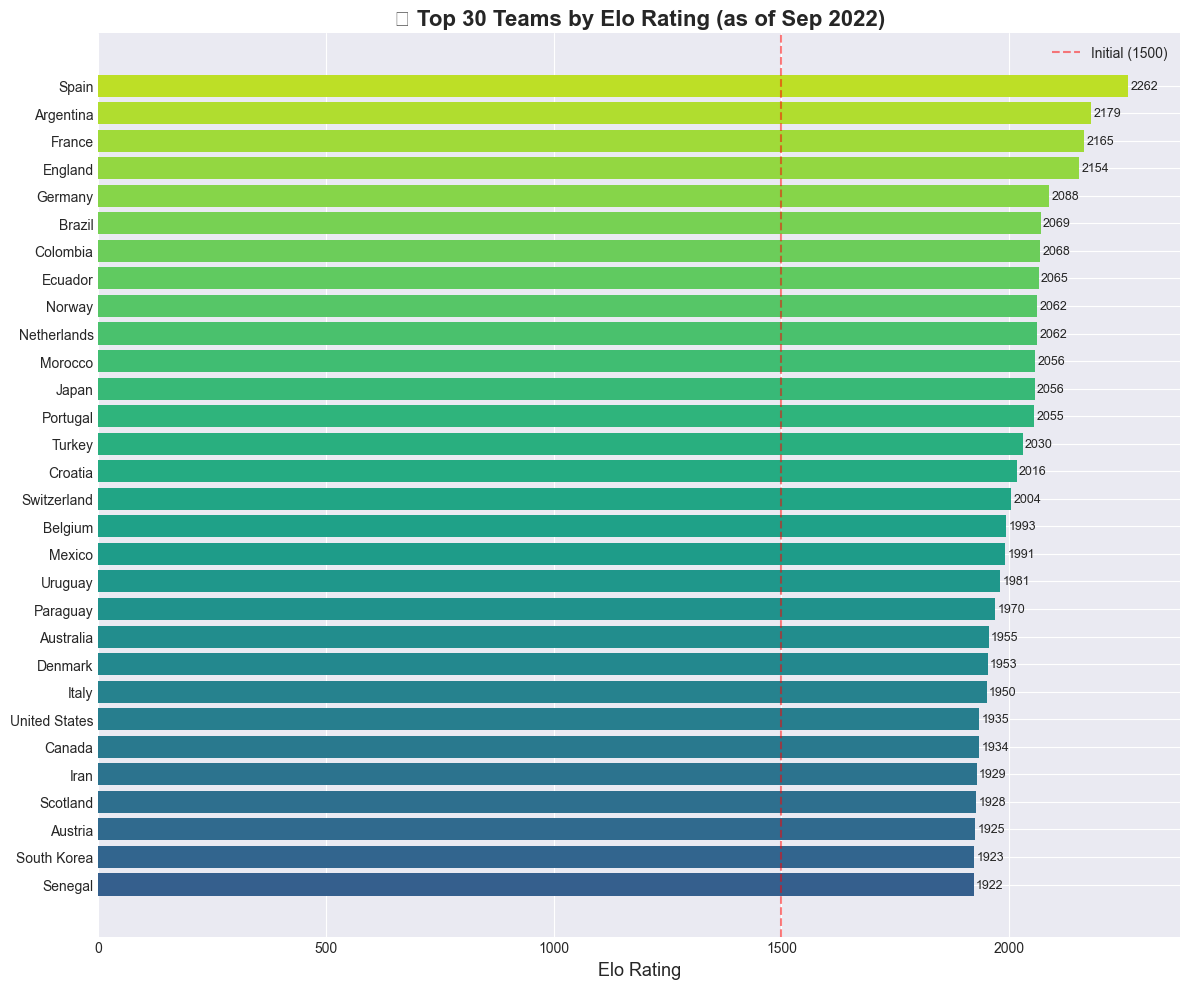

In [4]:
# Top 30 Elo Ratings (final)
all_ratings = elo.get_all_ratings()
top30 = dict(list(all_ratings.items())[:30])

fig, ax = plt.subplots(figsize=(12, 10))
teams = list(top30.keys())[::-1]
ratings = [top30[t] for t in teams]
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(teams)))

bars = ax.barh(teams, ratings, color=colors)
ax.axvline(x=1500, color='red', linestyle='--', alpha=0.5, label='Initial (1500)')
ax.set_xlabel('Elo Rating', fontsize=13)
ax.set_title('🏆 Top 30 Teams by Elo Rating (as of Sep 2022)', 
             fontsize=16, fontweight='bold')
ax.legend()

for bar, val in zip(bars, ratings):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/02_elo_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

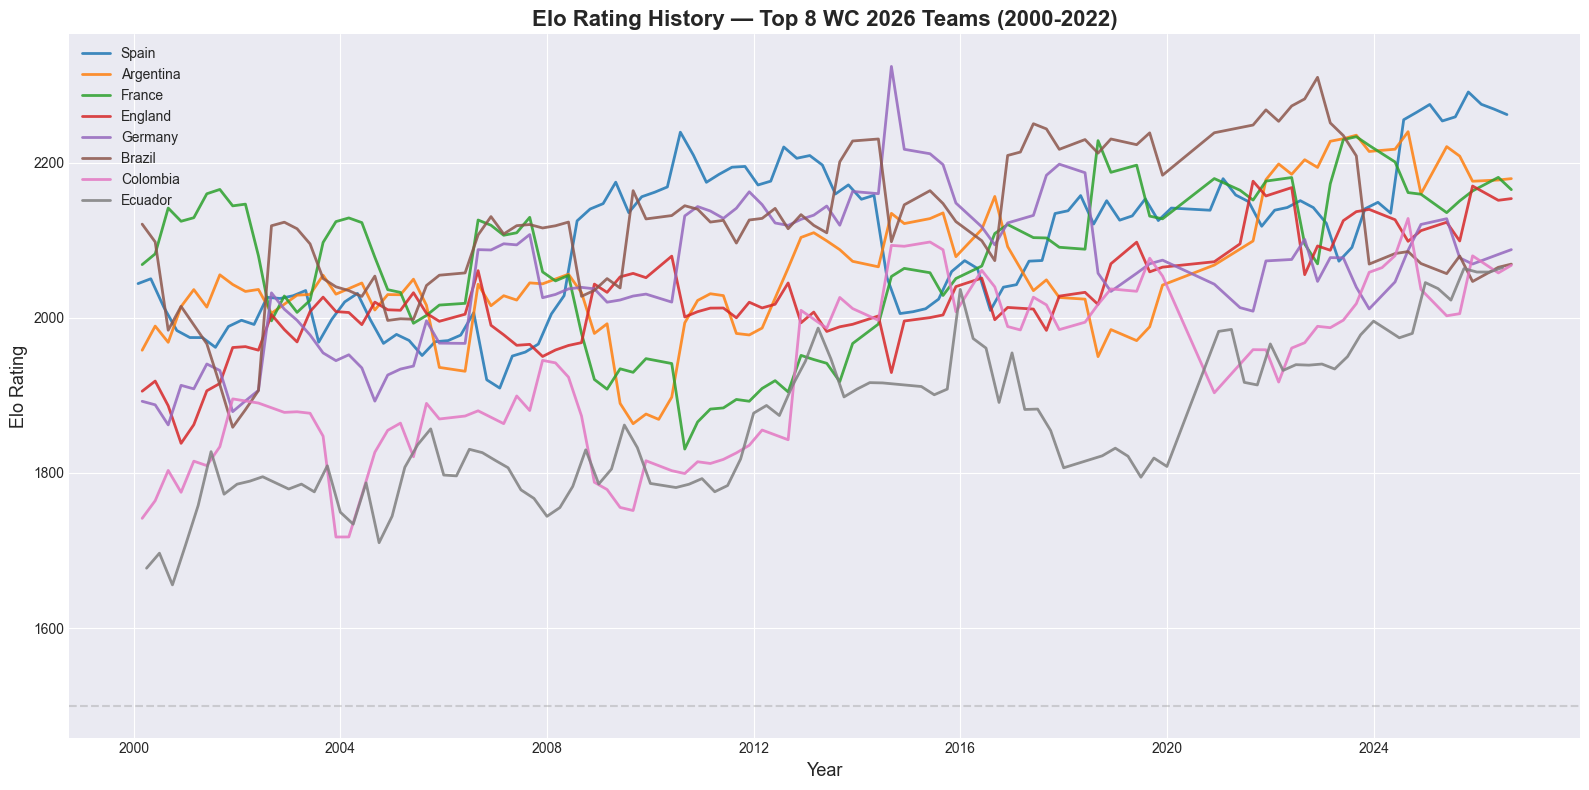

In [5]:
# Elo history untuk tim WC 2026 (dari 2000 ke atas)
history_df = elo.get_history_df()
history_df['date'] = pd.to_datetime(history_df['date'])

# Top 8 tim WC 2026 berdasarkan Elo
wc2026_team_list = wc2026_groups['Team'].tolist()
wc2026_elos = {t: elo.get_rating(t) for t in wc2026_team_list}
top8_wc2026 = sorted(wc2026_elos.items(), key=lambda x: -x[1])[:8]
top8_teams = [t[0] for t in top8_wc2026]

fig, ax = plt.subplots(figsize=(16, 8))

for team in top8_teams:
    # Get Elo trajectory for this team
    home_hist = history_df[history_df['home_team'] == team][['date', 'elo_home_after']].rename(
        columns={'elo_home_after': 'elo'})
    away_hist = history_df[history_df['away_team'] == team][['date', 'elo_away_after']].rename(
        columns={'elo_away_after': 'elo'})
    team_hist = pd.concat([home_hist, away_hist]).sort_values('date')
    team_hist = team_hist[team_hist['date'] >= '2000-01-01']
    
    if len(team_hist) > 0:
        # Resample to monthly for smoother lines
        team_hist = team_hist.set_index('date').resample('3ME').last().dropna()
        ax.plot(team_hist.index, team_hist['elo'], linewidth=2, label=team, alpha=0.85)

ax.set_title('Elo Rating History — Top 8 WC 2026 Teams (2000-2022)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Elo Rating', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
ax.axhline(y=1500, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/02_elo_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Build Feature Matrix

Kita akan membuat feature matrix untuk melatih model. Fitur dihitung untuk setiap pertandingan
berdasarkan data **sebelum** pertandingan tersebut (no data leakage).

In [6]:
# Filter pertandingan dengan skor (exclude yang belum dimainkan)
intl_valid = intl_with_elo.dropna(subset=['Home Goals', 'Away Goals']).copy()
intl_valid['Home Goals'] = intl_valid['Home Goals'].astype(int)
intl_valid['Away Goals'] = intl_valid['Away Goals'].astype(int)

# Target variable
intl_valid['result'] = 1  # Draw
intl_valid.loc[intl_valid['Home Goals'] > intl_valid['Away Goals'], 'result'] = 2  # Home Win
intl_valid.loc[intl_valid['Home Goals'] < intl_valid['Away Goals'], 'result'] = 0  # Away Win

print(f'Valid matches with scores: {len(intl_valid)}')
print(f'\nResult distribution:')
print(intl_valid['result'].value_counts().rename({0: 'Away Win', 1: 'Draw', 2: 'Home Win'}))

Valid matches with scores: 49378

Result distribution:
result
Home Win    24199
Away Win    13953
Draw        11226
Name: count, dtype: int64


In [7]:
# Hitung recent form untuk setiap pertandingan (vectorized approach untuk performa)
# Fokus pada pertandingan dari 2000 ke atas untuk training
print('Building form features (this may take a few minutes)...')

recent_data = intl_valid[intl_valid['Date'] >= '2000-01-01'].copy()
print(f'Training data: {len(recent_data)} matches from 2000 onwards')

# Pre-compute form features using rolling window approach
form_features = []

for idx, row in recent_data.iterrows():
    home = row['Home Team']
    away = row['Away Team']
    date = str(row['Date'])
    
    # Recent form (last 10 matches)
    home_form = calculate_recent_form(intl_valid, home, date, n_matches=10)
    away_form = calculate_recent_form(intl_valid, away, date, n_matches=10)
    
    feat = {
        'idx': idx,
        'elo_home': row['elo_home'],
        'elo_away': row['elo_away'],
        'elo_diff': row['elo_diff'],
        'home_win_rate': home_form['win_rate'],
        'home_avg_goals_scored': home_form['avg_goals_scored'],
        'home_avg_goals_conceded': home_form['avg_goals_conceded'],
        'home_goal_diff_avg': home_form['goal_diff_avg'],
        'away_win_rate': away_form['win_rate'],
        'away_avg_goals_scored': away_form['avg_goals_scored'],
        'away_avg_goals_conceded': away_form['avg_goals_conceded'],
        'away_goal_diff_avg': away_form['goal_diff_avg'],
        'form_diff': home_form['win_rate'] - away_form['win_rate'],
        'goal_diff_form': home_form['goal_diff_avg'] - away_form['goal_diff_avg'],
    }
    form_features.append(feat)

form_df = pd.DataFrame(form_features).set_index('idx')
print(f'Form features computed: {form_df.shape}')

Building form features (this may take a few minutes)...
Training data: 25316 matches from 2000 onwards


Form features computed: (25316, 13)


In [8]:
# WC Experience features per tim
print('Computing World Cup experience features...')

wc_exp_cache = {}
all_teams_in_data = set(recent_data['Home Team'].unique()) | set(recent_data['Away Team'].unique())

for team in all_teams_in_data:
    wc_exp_cache[team] = calculate_wc_experience(wc_matches, world_cups, team)

# Add WC features
wc_features = []
for idx, row in recent_data.iterrows():
    home = row['Home Team']
    away = row['Away Team']
    
    h_wc = wc_exp_cache.get(home, {'wc_appearances': 0, 'wc_titles': 0, 'wc_wins': 0})
    a_wc = wc_exp_cache.get(away, {'wc_appearances': 0, 'wc_titles': 0, 'wc_wins': 0})
    
    wc_features.append({
        'idx': idx,
        'home_wc_appearances': h_wc['wc_appearances'],
        'away_wc_appearances': a_wc['wc_appearances'],
        'home_wc_titles': h_wc['wc_titles'],
        'away_wc_titles': a_wc['wc_titles'],
        'wc_exp_diff': h_wc['wc_appearances'] - a_wc['wc_appearances'],
        'wc_titles_diff': h_wc['wc_titles'] - a_wc['wc_titles'],
    })

wc_df = pd.DataFrame(wc_features).set_index('idx')
print(f'WC experience features computed: {wc_df.shape}')

Computing World Cup experience features...


WC experience features computed: (25316, 6)


In [9]:
# Combine semua fitur
feature_matrix = recent_data[['Date', 'Home Team', 'Away Team', 'Tournament',
                               'Home Goals', 'Away Goals', 'result']].copy()
feature_matrix = feature_matrix.join(form_df)
feature_matrix = feature_matrix.join(wc_df)

# Add tournament type encoding
feature_matrix['is_wc'] = feature_matrix['Tournament'].str.contains('World Cup', na=False).astype(int)
feature_matrix['is_friendly'] = (feature_matrix['Tournament'] == 'Friendly').astype(int)
feature_matrix['is_qualifier'] = feature_matrix['Tournament'].str.contains('qualification|qualifier', 
                                                                             case=False, na=False).astype(int)

print(f'Final feature matrix: {feature_matrix.shape}')
print(f'\nFeature columns: {[c for c in feature_matrix.columns if c not in ["Date", "Home Team", "Away Team", "Tournament", "Home Goals", "Away Goals", "result"]]}')

feature_matrix.head()

Final feature matrix: (25316, 29)

Feature columns: ['elo_home', 'elo_away', 'elo_diff', 'home_win_rate', 'home_avg_goals_scored', 'home_avg_goals_conceded', 'home_goal_diff_avg', 'away_win_rate', 'away_avg_goals_scored', 'away_avg_goals_conceded', 'away_goal_diff_avg', 'form_diff', 'goal_diff_form', 'home_wc_appearances', 'away_wc_appearances', 'home_wc_titles', 'away_wc_titles', 'wc_exp_diff', 'wc_titles_diff', 'is_wc', 'is_friendly', 'is_qualifier']


,Date,Home Team,Away Team,Tournament,Home Goals,Away Goals,result,elo_home,elo_away,elo_diff,...,goal_diff_form,home_wc_appearances,away_wc_appearances,home_wc_titles,away_wc_titles,wc_exp_diff,wc_titles_diff,is_wc,is_friendly,is_qualifier
24062,2000-01-04,Egypt,Togo,Friendly,2,1,2,1714.566516,1485.840337,228.726179,...,0.3,3,1,0,0,2,0,0,1,0
24063,2000-01-07,Tunisia,Togo,Friendly,7,0,2,1724.942435,1481.612826,243.329609,...,1.6,6,1,0,0,5,0,0,1,0
24064,2000-01-08,Trinidad and Tobago,Canada,Friendly,0,0,1,1711.937475,1614.268881,97.668594,...,1.7,1,2,0,0,-1,0,0,1,0
24065,2000-01-09,Ivory Coast,Egypt,Friendly,2,0,2,1669.327309,1718.794027,-49.466719,...,0.9,3,3,0,0,0,0,0,1,0
24066,2000-01-09,Burkina Faso,Gabon,Friendly,1,1,1,1556.136843,1608.012252,-51.875409,...,-0.9,0,0,0,0,0,0,0,1,0


In [10]:
# Save feature matrix
feature_matrix.to_csv(OUTPUT_DIR / 'predictions' / 'feature_matrix.csv', index=False)
print(f'Feature matrix saved: {OUTPUT_DIR / "predictions" / "feature_matrix.csv"}')

# Save Elo ratings
elo_ratings_df = pd.DataFrame([
    {'Team': t, 'Elo': r} for t, r in elo.get_all_ratings().items()
])
elo_ratings_df.to_csv(OUTPUT_DIR / 'predictions' / 'elo_ratings.csv', index=False)
print(f'Elo ratings saved: {OUTPUT_DIR / "predictions" / "elo_ratings.csv"}')

Feature matrix saved: ..\outputs\predictions\feature_matrix.csv
Elo ratings saved: ..\outputs\predictions\elo_ratings.csv


## 4. Feature Correlation Analysis

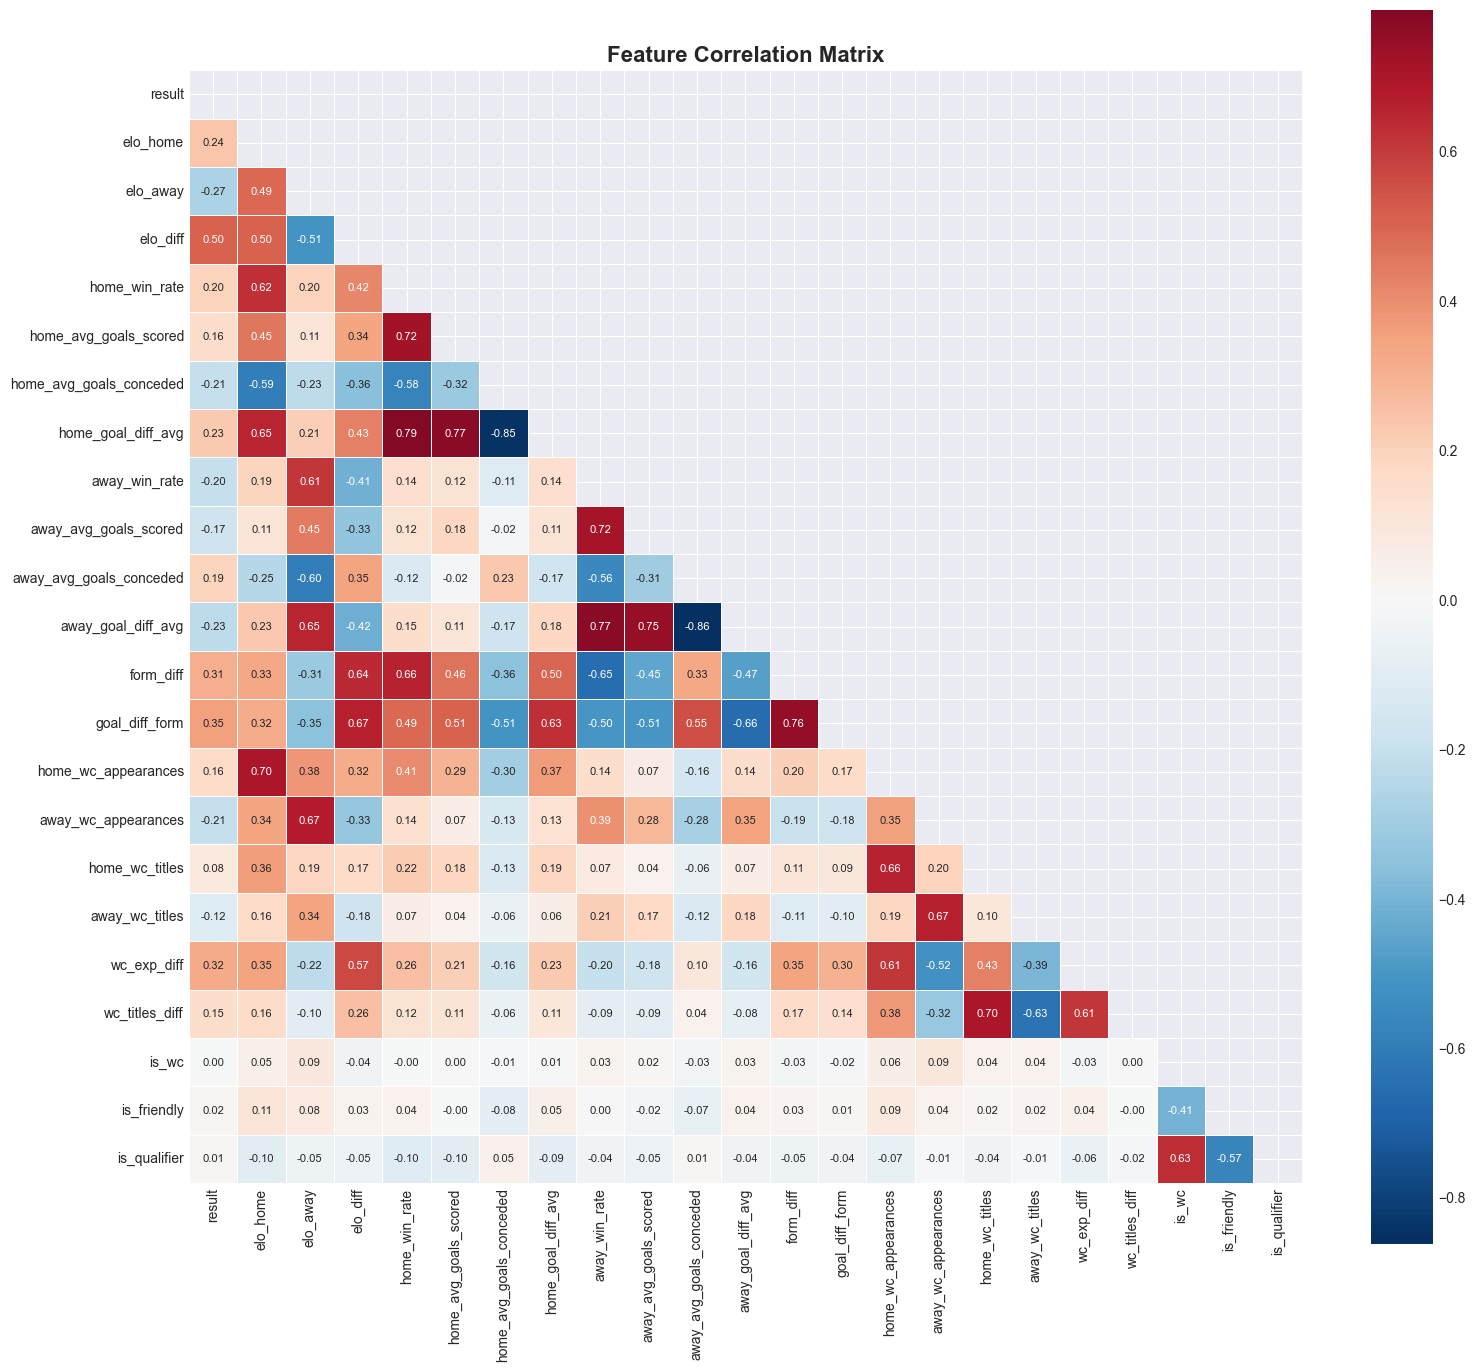

In [11]:
# Correlation heatmap
feature_cols = [c for c in feature_matrix.columns 
                if c not in ['Date', 'Home Team', 'Away Team', 'Tournament', 
                             'Home Goals', 'Away Goals']]

corr = feature_matrix[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. WC 2026 Team Feature Profiles

Hitung fitur untuk setiap tim WC 2026 (snapshot terbaru).

In [12]:
# Build feature profile for each WC 2026 team
wc2026_profiles = []
latest_date = str(intl_valid['Date'].max())

for _, row in wc2026_groups.iterrows():
    team = row['Team']
    
    profile = {
        'Team': team,
        'Group': row['Group'] if 'Group' in row.index else '',
        'FIFA_Ranking': row['FIFA Ranking'],
        'Elo': elo.get_rating(team),
    }
    
    # Recent form
    form = calculate_recent_form(intl_valid, team, latest_date, n_matches=10)
    profile['Win_Rate_Last10'] = form['win_rate']
    profile['Avg_Goals_Scored'] = form['avg_goals_scored']
    profile['Avg_Goals_Conceded'] = form['avg_goals_conceded']
    profile['Goal_Diff_Avg'] = form['goal_diff_avg']
    
    # WC experience
    wc_exp = wc_exp_cache.get(team, {'wc_appearances': 0, 'wc_titles': 0})
    profile['WC_Appearances'] = wc_exp['wc_appearances']
    profile['WC_Titles'] = wc_exp.get('wc_titles', 0)
    
    wc2026_profiles.append(profile)

wc2026_profile_df = pd.DataFrame(wc2026_profiles)
wc2026_profile_df = wc2026_profile_df.sort_values('Elo', ascending=False)

print('WC 2026 Team Profiles (sorted by Elo):')
wc2026_profile_df.to_string(index=False)

WC 2026 Team Profiles (sorted by Elo):


'                  Team Group  FIFA_Ranking         Elo  Win_Rate_Last10  Avg_Goals_Scored  Avg_Goals_Conceded  Goal_Diff_Avg  WC_Appearances  WC_Titles\n                 Spain     H             2 2261.917952              0.6               2.7                 0.5            2.2              16          1\n             Argentina     J             3 2179.336798              0.8               2.3                 0.3            2.0              18          2\n                France     I             1 2165.133334              0.8               2.4                 0.8            1.6              16          2\n               England     L             4 2153.572453              0.7               2.2                 0.5            1.7              16          1\n               Germany     E            10 2087.808624              0.9               2.8                 0.8            2.0              20          4\n                Brazil     C             6 2069.135769              0.6          

In [13]:
# Save WC 2026 profiles
wc2026_profile_df.to_csv(OUTPUT_DIR / 'predictions' / 'wc2026_team_profiles.csv', index=False)
print('WC 2026 team profiles saved!')

print('\n✅ Feature engineering complete! Next: 03_modeling.ipynb')

WC 2026 team profiles saved!

✅ Feature engineering complete! Next: 03_modeling.ipynb
